# Análise Exploratória — FIFA World Cup 2026 Player Performance

Este notebook é o ponto de partida do projeto: antes de treinar qualquer modelo de Machine Learning, precisamos entender os dados que temos em mãos — sua estrutura, granularidade, qualidade e as relações entre variáveis.

**O que é este dataset?** Uma simulação de performance de jogadores na Copa do Mundo de 2026, com uma linha por jogador *por partida* (não uma linha por jogador). São ~54.600 linhas, 1.248 jogadores e 1.050 partidas — em média um jogador aparece em ~44 linhas, bem mais do que os ~7 jogos de uma Copa real, o que confirma que os dados são sintéticos/simulados.

**Objetivo desta primeira etapa:** carregar os dados e fazer as primeiras verificações de sanidade (estrutura, tipos, nulos) antes de qualquer análise mais profunda.

## 1. Importando as ferramentas

Para esta etapa de exploração, precisamos de três tipos de ferramenta:

- **pandas**: estrutura de dados (`DataFrame`) e operações de manipulação/agregação.
- **matplotlib** e **seaborn**: visualização. O seaborn é construído sobre o matplotlib e facilita gráficos estatísticos (distribuições, correlações) com menos código.

Ainda não precisamos de nada de machine learning (scikit-learn) — isso entra só quando chegarmos na etapa de modelagem.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Carregando os dados

O arquivo `fifa_world_cup_2026_player_performance.csv` fica em `data/` (fora do controle de versão — é um dado grande demais e não faz sentido versionar no git). Vamos carregá-lo num `DataFrame` do pandas, que é a estrutura que vamos usar em todo o projeto.

In [2]:
data_df = pd.read_csv("../data/fifa_world_cup_2026_player_performance.csv")

data_df.shape

(54600, 75)

## 3. Primeira olhada nos dados

Antes de qualquer análise, vale ver algumas linhas reais do dataset — isso ajuda a confirmar que o `read_csv` interpretou tudo certo (colunas, tipos) e dá uma primeira sensação de como os dados se parecem.

In [3]:
data_df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


## 4. Estrutura e tipos das colunas

Com 75 colunas, é fácil perder a noção do que temos. O `info()` mostra, de uma vez, o tipo de cada coluna (numérica, texto) e quantos valores não-nulos ela tem — o que já adianta parte da checagem de qualidade dos dados.

In [4]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

## 5. Valores nulos

Dados faltantes podem quebrar contas (médias, correlações) ou exigir tratamento (imputação, remoção) antes de qualquer modelo. Vamos contar nulos por coluna.

In [5]:
data_df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

## 6. Linhas duplicadas

Linhas duplicadas inflariam artificialmente certas estatísticas (contagens, médias) e poderiam vazar a mesma observação para treino e teste no futuro. `duplicated()` marca linhas que são cópia exata de outra; somamos para saber quantas existem.

In [6]:
data_df.duplicated().sum()

np.int64(0)

## 7. Definindo o alvo do modelo

Antes de escolher features, precisamos decidir o que o modelo vai prever. Duas opções faziam sentido com esse dataset:

- **Classificação** em `player_of_match_awards` (virou ou não "melhor em campo" na partida) — mais alinhado ao nome do projeto, mas o alvo é bem desbalanceado (97.5% das linhas são 0).
- **Regressão** em `player_rating` (a nota da partida) — alvo contínuo, sem desbalanceamento, e ainda assim responde a uma pergunta interessante: *o que faz um jogador tirar uma nota alta numa partida?*

Decidimos seguir com a **regressão em `player_rating`** — é o ponto de partida mais simples para validar o pipeline inteiro (dados → features → modelo → avaliação) antes de partir para um problema mais difícil como a classificação desbalanceada.

In [7]:
data_df["player_rating"].describe()

count    54600.000000
mean         3.634700
std          3.155846
min          0.000000
25%          0.000000
50%          5.500000
75%          6.400000
max          9.400000
Name: player_rating, dtype: float64

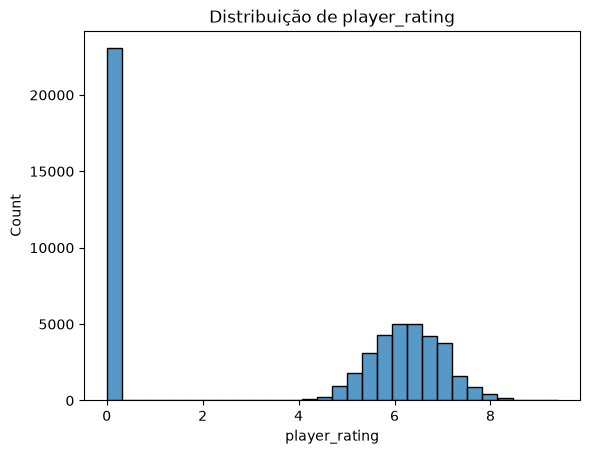

In [8]:
sns.histplot(data=data_df, x="player_rating", bins=30)
plt.title("Distribuição de player_rating")
plt.show()

## 8. Investigando vazamento de dados (data leakage)

Antes de escolher quais colunas usar como features, precisamos checar se alguma delas é, na prática, uma versão disfarçada do próprio alvo. Isso se chama **vazamento de dados (data leakage)**: se uma feature já "contém" a resposta, o modelo não aprende nada de real — ele só copia a fórmula, e vai parecer ótimo nas métricas enquanto é inútil na prática.

O jeito mais simples de detectar isso é olhar a correlação de cada coluna numérica com `player_rating`. Correlações muito próximas de 1 são um sinal de alerta.

In [9]:
numeric_df = data_df.select_dtypes(include="number")

correlation_with_rating = numeric_df.corr()["player_rating"].sort_values(ascending=False)
correlation_with_rating

player_rating             1.000000
tournament_rating         0.997337
performance_score         0.996610
top_speed_kmh             0.979422
distance_covered_km       0.837282
                            ...   
defensive_contribution   -0.015169
penalty_saves            -0.032162
age                      -0.038601
weight_kg                -0.047483
height_cm                -0.079225
Name: player_rating, Length: 61, dtype: float64

Dá pra ver que `tournament_rating` (0.997), `performance_score` (0.997) e `top_speed_kmh` (0.979) têm correlação absurdamente alta com `player_rating`. `tournament_rating` faz sentido ficar de fora por ser praticamente o mesmo tipo de nota que o alvo (não uma feature, é quase um sinônimo). Já `performance_score` e `top_speed_kmh` merecem mais investigação — talvez sejam literalmente os ingredientes usados para gerar a nota sintética.

Também chamam atenção `possession_impact` (0.62) e `stamina_score` (0.56) — bem mais altos que qualquer estatística "crua" de partida (ex: `goals` tem só 0.22). Isso pode ser vazamento também, ou pode ser apenas correlação natural (jogadores com mais posse/stamina realmente jogam melhor). Uma correlação simples não separa as duas hipóteses — para isso, vamos testar quanto desses 4 "suspeitos" conseguem prever `player_rating` sozinhos, com uma regressão linear.

Aqui usamos o scikit-learn um pouco antes do previsto (a ideia original era só na etapa de modelagem) — mas é só como ferramenta de diagnóstico, para medir *quanto* dessas colunas explicam o alvo (R²), não para treinar o modelo final do projeto.

In [10]:
from sklearn.linear_model import LinearRegression

suspects = ["performance_score", "top_speed_kmh", "possession_impact", "stamina_score"]
y = data_df["player_rating"]

for cols in [suspects, ["performance_score", "top_speed_kmh"], ["performance_score"]]:
    r2 = LinearRegression().fit(data_df[cols], y).score(data_df[cols], y)
    print(f"R² usando {cols}: {r2:.4f}")

R² usando ['performance_score', 'top_speed_kmh', 'possession_impact', 'stamina_score']: 0.9944
R² usando ['performance_score', 'top_speed_kmh']: 0.9943
R² usando ['performance_score']: 0.9932


O resultado é bem claro: **`performance_score` sozinho já explica ~99.3%** da variância de `player_rating`. Adicionar `top_speed_kmh` sobe pra ~99.4%. Adicionar também `possession_impact` e `stamina_score` não muda quase nada o R² — e os coeficientes deles na regressão com os 4 juntos são praticamente zero.

Isso separa as duas hipóteses:

- **`performance_score` e `top_speed_kmh` são vazamento de verdade** — muito provavelmente foram os ingredientes usados para gerar `player_rating` de forma sintética. **Vão ficar de fora das features.**
- **`possession_impact` e `stamina_score` não são vazamento** — a correlação alta que vimos antes é só porque eles também se correlacionam com `performance_score` (que por sua vez é redundante com o alvo), não porque carregam informação extra sobre a nota. São features legítimas e podem entrar no modelo.

### Um detalhe que vale checar antes de fechar a conclusão

`top_speed_kmh` tem correlação de 0.98 com `player_rating`, mas seu coeficiente na regressão com os 4 suspeitos juntos foi bem menor que o de `performance_score`. Vale desconfiar: será que essa correlação alta é uma relação real, ou um artefato de outra coisa?

Uma hipótese: parte das 54.600 linhas são jogadores que **não entraram em campo** (`minutes_played == 0`). Para essas linhas, tanto `top_speed_kmh` quanto `player_rating` são zero por definição (não porque um cause o outro, mas porque não há partida pra medir). Se essa fatia for grande, ela infla a correlação geral sem representar uma relação real entre as duas variáveis.

Vamos checar quantas linhas são essas e recalcular a correlação só entre quem realmente jogou.

In [11]:
played_df = data_df[data_df["minutes_played"] > 0]

print(f"Linhas com minutes_played == 0: {(data_df['minutes_played'] == 0).sum()} de {len(data_df)} ({(data_df['minutes_played'] == 0).mean():.1%})")
print()
print("Correlação com player_rating, só entre quem jogou:")
print(played_df[["performance_score", "top_speed_kmh"]].corrwith(played_df["player_rating"]))

Linhas com minutes_played == 0: 23042 de 54600 (42.2%)

Correlação com player_rating, só entre quem jogou:
performance_score    0.926060
top_speed_kmh        0.022731
dtype: float64


Confirmado: **42% das linhas (23.042 de 54.600) são jogadores que não jogaram** — convocados que ficaram no banco. Entre quem realmente jogou, a correlação de `top_speed_kmh` com `player_rating` cai de 0.98 para **0.02** (basicamente nula). Já `performance_score` continua em 0.93 — a correlação alta dele não era artefato, é vazamento de verdade.

Isso muda a conclusão sobre `top_speed_kmh`: **não é vazamento**, mas também não tem sinal nenhum como feature — a correlação que víamos era só o efeito colateral de estar zerado junto com o alvo nas linhas de quem não jogou. Fica de fora do modelo, mas por ser inútil, não por vazar informação.

E isso levanta uma questão maior: será que faz sentido incluir as linhas de `minutes_played == 0` no modelo? Prever `player_rating = 0` para quem não jogou é trivial (o dado já entrega a resposta via `minutes_played`) e infla artificialmente qualquer métrica de acerto. **Decisão para o próximo notebook:** filtrar o dataset para `minutes_played > 0` antes de treinar — o problema interessante é prever a nota de quem efetivamente jogou.

## 9. Checando os totais acumulados de torneio

Ainda restam `total_goals_tournament`, `total_assists_tournament` e `total_minutes_tournament`. A princípio parecem úteis (representariam a "forma" do jogador no torneio), mas têm um problema em potencial: se esse total *já inclui* os gols/assistências/minutos da própria partida que estamos tentando avaliar, isso é vazamento temporal — a feature conteria parte do resultado que queremos prever.

Para checar, vamos pegar um jogador que marcou vários gols ao longo do torneio e comparar, partida a partida, os `goals` daquela linha com o `total_goals_tournament` da mesma linha. Se for um total acumulado de verdade, os valores deveriam crescer de forma consistente com a soma dos gols anteriores.

In [12]:
data_df["match_date"] = pd.to_datetime(data_df["match_date"])

goals_by_player = data_df.groupby("player_id")["goals"].sum()
sample_player = goals_by_player[goals_by_player > 5].index[0]

sample = data_df[data_df["player_id"] == sample_player].sort_values("match_date")
sample[["match_date", "goals", "total_goals_tournament"]]

,match_date,goals,total_goals_tournament
47228,2026-06-13,0,2
49273,2026-06-14,1,1
36422,2026-06-19,0,4
13999,2026-06-20,0,2
46677,2026-06-21,0,2
31414,2026-06-21,0,4
47692,2026-06-23,0,0
35481,2026-06-23,0,3
45983,2026-06-24,0,1
41341,2026-06-24,1,2


Os valores de `total_goals_tournament` oscilam (sobe e desce) partida a partida, sem nenhuma relação consistente com os gols acumulados de fato — ou seja, **não é um total acumulado real**, é ruído sintético independente. Isso é mais uma pista de que o dataset não tem uma progressão temporal coerente por trás (esperado, já que cada jogador tem ~44 "partidas" simuladas, muito mais que uma Copa real).

Conclusão prática: essas três colunas (`total_goals_tournament`, `total_assists_tournament`, `total_minutes_tournament`) não vazam a partida atual (não há uma relação determinística clara), mas também não carregam sinal confiável de "forma do jogador" — vão ficar de fora das features por não serem confiáveis, não por serem vazamento.

## 10. Conclusão — o que fica de fora das features

Resumindo o que decidimos até aqui para prever `player_rating`:

**Escopo dos dados:**
- Filtrar para `minutes_played > 0` antes de treinar — 42% das linhas são jogadores que não entraram em campo, onde a nota é trivialmente 0. Incluir essas linhas infla artificialmente qualquer métrica do modelo.

**Fora do modelo:**
- `player_id`, `player_name`, `match_id` — identificadores, sem valor preditivo.
- `performance_score` — vazamento de dados confirmado (R² de 93% sozinho, mesmo só entre quem jogou).
- `top_speed_kmh` — a correlação alta (0.98) era um artefato das linhas de quem não jogou; entre quem jogou, cai para ~0.02. Não é vazamento, mas também não tem sinal — fica de fora por ser inútil.
- `tournament_rating` — praticamente idêntico ao alvo (corr. 0.92+ mesmo só entre quem jogou), não é uma feature de verdade.
- `total_goals_tournament`, `total_assists_tournament`, `total_minutes_tournament` — não são vazamento, mas também não são confiáveis (ruído sintético sem coerência temporal).
- `player_of_match_awards` — é outro resultado pós-partida (como o próprio rating), não uma causa dele; faz mais sentido tratá-lo como um possível alvo alternativo no futuro do que como feature.

**Seguem candidatas a features:** os atributos do jogador (idade, altura, peso, posição, pé preferido, valor de mercado), o contexto categórico da partida (adversário, fase do torneio, mandante/visitante), e as estatísticas brutas da partida (gols, assistências, passes, ações defensivas, físico) — incluindo `possession_impact` e `stamina_score`, que investigamos e não são vazamento.

O próximo notebook (`02_feature_engineering`) parte daqui: filtrar `minutes_played > 0`, selecionar essas colunas de fato, tratar as categóricas de alta cardinalidade (`nationality`, `team`, `club_name`) e preparar os dados pro modelo.